# VeriLens — Complete Paper Revision Pipeline

Run every cell in order. Generates ALL reviewer-requested figures & metrics.

In [1]:
# !pip install tensorflow

## 2. Imports & GPU Setup

In [2]:
import os, sys, json, time, pickle
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import cv2
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print('✅ Mixed precision enabled')
except:
    print('ℹ️ Mixed precision not available')

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'✅ GPU(s): {[g.name for g in gpus]}')
else:
    print('⚠️ No GPU found')

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.utils import to_categorical, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence as KerasSequence

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, auc, classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    precision_recall_fscore_support
)
from tqdm.auto import tqdm

print('✅ All imports successful')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6


✅ Mixed precision enabled
✅ GPU(s): ['/physical_device:GPU:0']


✅ All imports successful


c:\Users\blaze\miniconda3\envs\deepfake\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Configuration

**Edit these paths** to match your setup.

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EDIT THESE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET_NAME = 'dfdc'
REAL_DIR = './data/DFDC-real'
FAKE_DIR = './data/DFDC-fake'

# Feature cache
SEQUENCE_LENGTH = 15
FRAME_STRIDE = 15
CACHE_DIR = Path(f'cache/{DATASET_NAME}/seq{SEQUENCE_LENGTH}_stride{FRAME_STRIDE}')
CACHE_REAL = CACHE_DIR / 'real'
CACHE_FAKE = CACHE_DIR / 'fake'
CACHE_REAL.mkdir(parents=True, exist_ok=True)
CACHE_FAKE.mkdir(parents=True, exist_ok=True)

RESULTS_BASE = Path(f'results/{DATASET_NAME}')

# LRCN Original
LRCN_EPOCHS = 10
LRCN_BATCH = 2
LRCN_LR = 1e-4

# LRCN Retrained
RETRAIN_EPOCHS = 15
RETRAIN_BATCH = 32
RETRAIN_LR = 1e-4
FOCAL_GAMMA = 2.0

NUM_TIMING_VIDEOS = 10
SKIP_FEATURE_EXTRACTION = False

print(f'Dataset: {DATASET_NAME}')
print(f'Real: {REAL_DIR} | Fake: {FAKE_DIR}')

Dataset: dfdc
Real: ./data/DFDC-real | Fake: ./data/DFDC-fake


## 4. Download Dataset (skip if already have videos)

In [4]:
DOWNLOAD_DATASET = False  # Set True to download from Kaggle
import os
import json
if DOWNLOAD_DATASET:
    !pip install -q kaggle
    os.makedirs('/root/.kaggle', exist_ok=True)
    KAGGLE_USERNAME = 'abdulrahimm'
    KAGGLE_KEY = 'KGAT_06d73f5c36f04253bb5bc3320579ce42'
    with open('/root/.kaggle/kaggle.json', 'w') as f:
        json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}, f)
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    !kaggle datasets download -d reubensuju/celeb-df-v2 -p ./data --unzip

real_count = len([f for f in os.listdir(REAL_DIR) if f.endswith('.mp4')]) if os.path.isdir(REAL_DIR) else 0
fake_count = len([f for f in os.listdir(FAKE_DIR) if f.endswith('.mp4')]) if os.path.isdir(FAKE_DIR) else 0
print(f'Real: {real_count} | Fake: {fake_count}')
if real_count == 0 or fake_count == 0:
    print('❌ No videos found! Fix REAL_DIR/FAKE_DIR in Cell 3')
else:
    print(f'✅ Total: {real_count + fake_count} videos')

Real: 194 | Fake: 2839
✅ Total: 3033 videos


## 5. Core Functions

In [5]:
def list_videos(folder):
    if not os.path.isdir(folder): return []
    return sorted([os.path.join(folder, f) for f in os.listdir(folder)
                   if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))])

def extract_faces_from_video(video_path, seq_len=SEQUENCE_LENGTH, stride=FRAME_STRIDE):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return np.zeros((seq_len, 224, 224, 3), dtype=np.uint8), {}
    cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces, idx = [], 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if idx % stride == 0:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            det = cascade.detectMultiScale(gray, 1.3, 5)
            if len(det) > 0:
                x, y, w, h = max(det, key=lambda b: b[2]*b[3])
                crop = frame[y:y+h, x:x+w]
            else:
                h, w, _ = frame.shape
                sz = min(h, w)
                y0, x0 = (h-sz)//2, (w-sz)//2
                crop = frame[y0:y0+sz, x0:x0+sz]
            crop = cv2.cvtColor(cv2.resize(crop, (224, 224)), cv2.COLOR_BGR2RGB)
            faces.append(crop)
        idx += 1
        if len(faces) >= seq_len: break
    cap.release()
    while len(faces) < seq_len:
        faces.append(np.zeros((224, 224, 3), dtype=np.uint8))
    return np.array(faces[:seq_len], dtype=np.uint8), {}

def faces_to_features(faces, vgg):
    x = np.array([preprocess_input(img_to_array(f)) for f in faces])
    return vgg.predict(x, batch_size=len(x), verbose=0).astype(np.float32)

def extract_and_cache(video_path, class_name, vgg):
    fname = Path(video_path).stem + '.npy'
    cpath = str((CACHE_REAL if class_name == 'real' else CACHE_FAKE) / fname)
    if os.path.exists(cpath):
        arr = np.load(cpath)
        if arr.ndim == 2 and arr.shape[0] == SEQUENCE_LENGTH:
            return arr
    if SKIP_FEATURE_EXTRACTION:
        raise RuntimeError(f'Cache miss: {cpath}')
    faces, _ = extract_faces_from_video(video_path)
    features = faces_to_features(faces, vgg)
    np.save(cpath, features)
    return features

print('✅ Core functions defined')

✅ Core functions defined


## 6. Evaluation & Plotting Functions

In [6]:
def compute_all_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    m = {
        'confusion_matrix': {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)},
        'total_samples': int(total),
        'accuracy': round((tp+tn)/total, 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_true, y_pred), 4),
        'precision_real': round(tp/(tp+fp), 4) if (tp+fp) > 0 else 0,
        'recall_real': round(tp/(tp+fn), 4) if (tp+fn) > 0 else 0,
        'f1_real': round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'specificity': round(tn/(tn+fp), 4) if (tn+fp) > 0 else 0,
        'f1_fake': round(f1_score(y_true, y_pred, pos_label=0, zero_division=0), 4),
        'class_dist': {'fake': int((y_true==0).sum()), 'real': int((y_true==1).sum()),
                       'ratio': round((y_true==0).sum()/max((y_true==1).sum(),1), 2)},
    }
    if len(set(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        m['roc_auc'] = round(auc(fpr, tpr), 4)
        m['avg_precision'] = round(average_precision_score(y_true, y_score), 4)
    return m

def tune_threshold(y_true, y_score):
    best_t, best_f1, best_s = 0.5, -1, {}
    for t in np.linspace(0.05, 0.95, 181):
        yp = (y_score >= t).astype(int)
        p, r, f, _ = precision_recall_fscore_support(y_true, yp, labels=[0,1], zero_division=0)
        if f[1] > best_f1:
            best_f1, best_t = f[1], float(t)
            best_s = {'t': round(best_t,3), 'prec': round(float(p[1]),4),
                       'rec': round(float(r[1]),4), 'f1': round(float(f[1]),4)}
    return best_t, best_s

def plot_all(y_true, y_pred, y_score, model_name, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if len(set(y_true)) < 2:
        print('⚠️ Single class — skipping plots')
        return

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax.plot([0,1],[0,1],'--',color='gray')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {model_name}'); ax.legend(); ax.grid(alpha=0.3)
    fig.savefig(out_dir/'ROC_curve.png', dpi=200, bbox_inches='tight')
    plt.show(); plt.close()

    prec_arr, rec_arr, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    baseline = y_true.sum()/len(y_true)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.plot(rec_arr, prec_arr, lw=2, color='#C0392B', label=f'PR (AP = {ap:.3f})')
    ax.axhline(baseline, ls='--', color='gray', label=f'Baseline ({baseline:.3f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall — {model_name}')
    ax.legend(); ax.grid(alpha=0.3); ax.set_xlim(0,1); ax.set_ylim(0,1)
    fig.savefig(out_dir/'PR_curve.png', dpi=200, bbox_inches='tight')
    plt.show(); plt.close()

    thresholds = np.arange(0.05, 0.96, 0.01)
    ps, rs, fs, bas = [], [], [], []
    for t in thresholds:
        yp = (y_score >= t).astype(int)
        if len(set(yp)) < 2:
            ps.append(np.nan); rs.append(np.nan); fs.append(np.nan); bas.append(np.nan)
            continue
        ps.append(precision_score(y_true, yp, zero_division=0))
        rs.append(recall_score(y_true, yp, zero_division=0))
        fs.append(f1_score(y_true, yp, zero_division=0))
        bas.append(balanced_accuracy_score(y_true, yp))
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(thresholds, ps, 'b-', lw=2, label='Precision')
    ax.plot(thresholds, rs, 'r-', lw=2, label='Recall')
    ax.plot(thresholds, fs, 'g-', lw=2, label='F1')
    ax.plot(thresholds, bas, 'm--', lw=2, label='Balanced Acc')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_title(f'Threshold Analysis — {model_name}')
    ax.legend(loc='center left'); ax.grid(alpha=0.3)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    fig.savefig(out_dir/'threshold_analysis.png', dpi=200, bbox_inches='tight')
    plt.show(); plt.close()

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, cmap=plt.cm.Blues)
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.colorbar(im)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Fake','Real'], rotation=45)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Fake','Real'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=14,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    fig.savefig(out_dir/'confusion_matrix.png', dpi=200, bbox_inches='tight')
    plt.show(); plt.close()

def full_eval(y_true, y_pred, y_score, model_name, out_dir, history=None):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    metrics = compute_all_metrics(y_true, y_pred, y_score)
    best_t, thresh_stats = tune_threshold(y_true, y_score)
    metrics['best_threshold'] = thresh_stats
    metrics['model'] = model_name
    metrics['dataset'] = DATASET_NAME
    with open(out_dir/'metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)
    cm = metrics['confusion_matrix']
    ver = (f"From the {model_name} confusion matrix "
           f"(TN={cm['TN']}, FP={cm['FP']}, FN={cm['FN']}, TP={cm['TP']}): "
           f"Precision(Real)={metrics['precision_real']}, "
           f"Recall(Real)={metrics['recall_real']}, "
           f"Accuracy={metrics['accuracy']}, "
           f"F1(Real)={metrics['f1_real']}, "
           f"Specificity={metrics['specificity']}, "
           f"Balanced Accuracy={metrics['balanced_accuracy']}.")
    with open(out_dir/'verification.txt', 'w') as f:
        f.write(ver)
    report = classification_report(y_true, y_pred, digits=4, target_names=['Fake','Real'])
    with open(out_dir/'classification_report.txt', 'w') as f:
        f.write(report)
    plot_all(y_true, y_pred, y_score, model_name, out_dir)
    if history:
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(14,5))
        a1.plot(history.history['loss'], label='Train')
        a1.plot(history.history.get('val_loss',[]), label='Val')
        a1.set_title('Loss'); a1.legend(); a1.grid(alpha=0.3)
        a2.plot(history.history['accuracy'], label='Train')
        a2.plot(history.history.get('val_accuracy',[]), label='Val')
        a2.set_title('Accuracy'); a2.legend(); a2.grid(alpha=0.3)
        fig.savefig(out_dir/'training_history.png', dpi=200, bbox_inches='tight')
        plt.show(); plt.close()
    d = metrics['class_dist']
    print(f"\n{'='*55}")
    print(f"  {model_name} on {DATASET_NAME}")
    print(f"{'='*55}")
    print(f"  Samples: {metrics['total_samples']} ({d['fake']}F, {d['real']}R, {d['ratio']}:1)")
    print(f"  Accuracy:          {metrics['accuracy']}")
    print(f"  Balanced Accuracy: {metrics['balanced_accuracy']}")
    print(f"  Precision(Real):   {metrics['precision_real']}")
    print(f"  Recall(Real):      {metrics['recall_real']}")
    print(f"  F1(Real):          {metrics['f1_real']}")
    print(f"  Specificity:       {metrics['specificity']}")
    if 'roc_auc' in metrics: print(f"  ROC AUC:           {metrics['roc_auc']}")
    print(f"  Best threshold:    {best_t:.3f} -> F1={thresh_stats['f1']}")
    print(f"  Saved to {out_dir}/")
    print(f"  Verification: {ver[:100]}...")
    return metrics

print('✅ Evaluation functions defined')

✅ Evaluation functions defined


## 7. Extract VGG16 Features

Slow first run (~30-60 min). Cached after that.

In [7]:
vgg = VGG16(weights='imagenet', include_top=False, pooling='avg')
print('✅ VGG16 loaded')

real_videos = list_videos(REAL_DIR)
fake_videos = list_videos(FAKE_DIR)
print(f'Real: {len(real_videos)} | Fake: {len(fake_videos)}')

print('\nExtracting real...')
X_real = []
for vp in tqdm(real_videos, desc='Real'):
    X_real.append(extract_and_cache(vp, 'real', vgg))

print('\nExtracting fake...')
X_fake = []
for vp in tqdm(fake_videos, desc='Fake'):
    X_fake.append(extract_and_cache(vp, 'fake', vgg))

X_real = np.stack(X_real)
X_fake = np.stack(X_fake)
y_real = np.ones(len(X_real), dtype=np.int32)
y_fake = np.zeros(len(X_fake), dtype=np.int32)
X = np.concatenate([X_real, X_fake])
y = np.concatenate([y_real, y_fake])
T, F = X.shape[1], X.shape[2]
print(f'\n✅ X={X.shape}, y={y.shape}')
print(f'   Fake: {(y==0).sum()}, Real: {(y==1).sum()}')

✅ VGG16 loaded
Real: 194 | Fake: 2839

Extracting real...


Real:   0%|          | 0/194 [00:00<?, ?it/s]

Real:  11%|█         | 21/194 [00:00<00:00, 203.30it/s]

Real:  22%|██▏       | 42/194 [00:00<00:00, 169.46it/s]

Real:  31%|███       | 60/194 [00:00<00:00, 160.75it/s]

...

Fake:  98%|█████████▊| 2770/2839 [00:14<00:00, 186.94it/s]

Fake:  98%|█████████▊| 2792/2839 [00:14<00:00, 193.18it/s]

Fake:  99%|█████████▉| 2816/2839 [00:14<00:00, 196.75it/s]

Fake: 100%|██████████| 2839/2839 [00:15<00:00, 188.96it/s]


✅ X=(3033, 15, 512), y=(3033,)
   Fake: 2839, Real: 194


## 8. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Test: Fake={( y_test==0).sum()}, Real={(y_test==1).sum()}')
print(f'Imbalance: {(y_test==0).sum()/max((y_test==1).sum(),1):.1f}:1')

Train: 2426 | Test: 607
Test: Fake=568, Real=39
Imbalance: 14.6:1


## 9. LRCN Original

`TimeDistributed(Dense(256))` → `Dropout(0.3)` → `LSTM(128)` → `Dropout(0.3)` → `Dense(2, softmax)`

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 time_distributed (TimeDistr  (None, 15, 256)          131328    


 ibuted)                                                         


...

950/970 [============================>.] - ETA: 0s - loss: 0.1571 - accuracy: 0.9474

965/970 [============================>.] - ETA: 0s - loss: 0.1583 - accuracy: 0.9472

970/970 [==============================] - 4s 4ms/step - loss: 0.1580 - accuracy: 0.9474 - val_loss: 0.2268 - val_accuracy: 0.9115


 1/19 [>.............................] - ETA: 5s

19/19 [==============================] - 0s 2ms/step


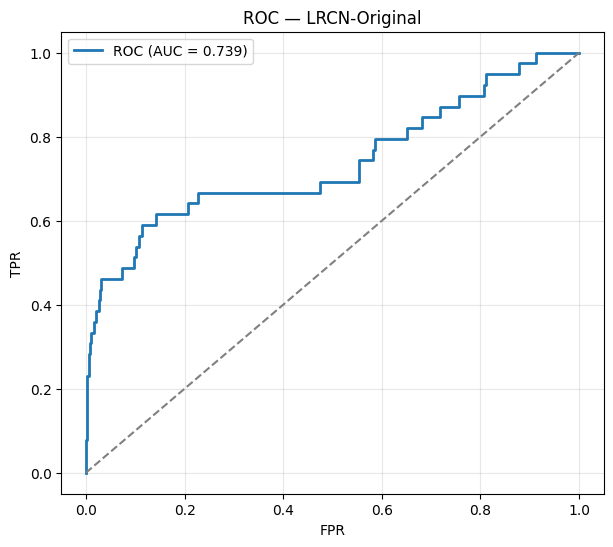

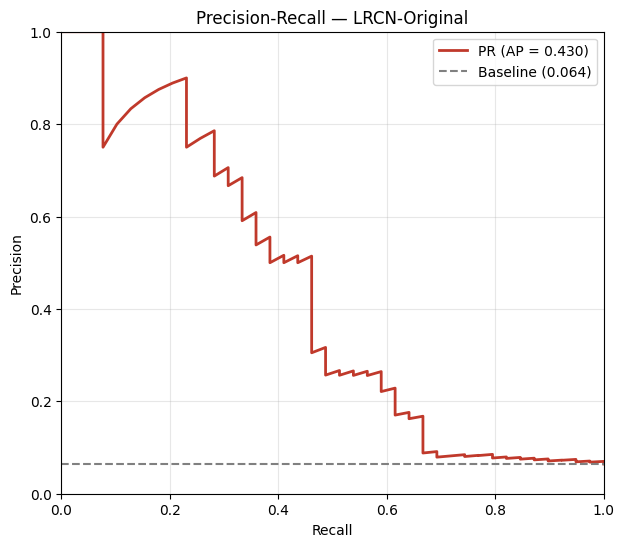

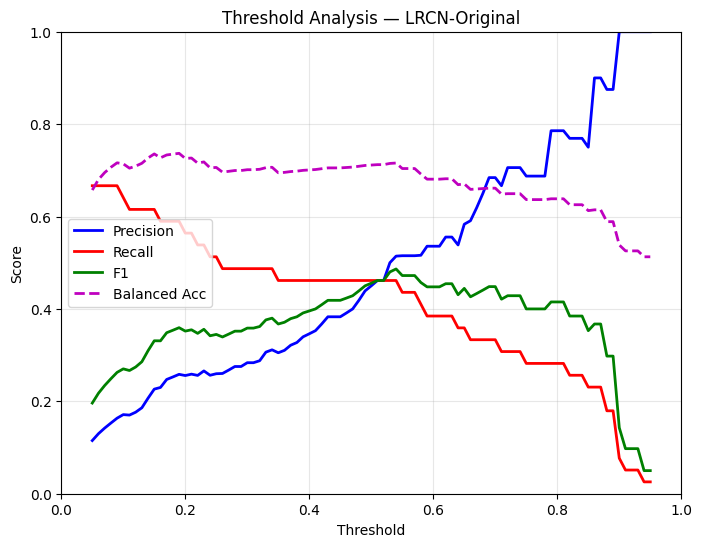

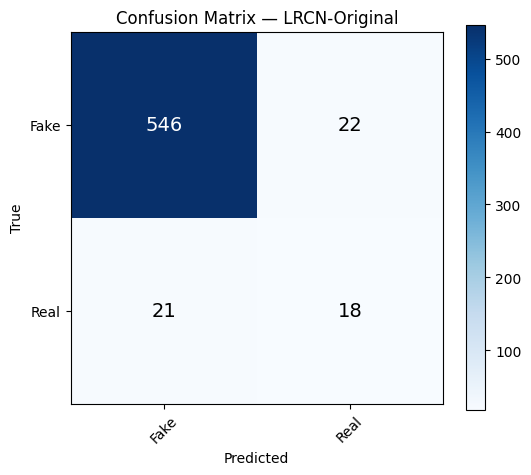

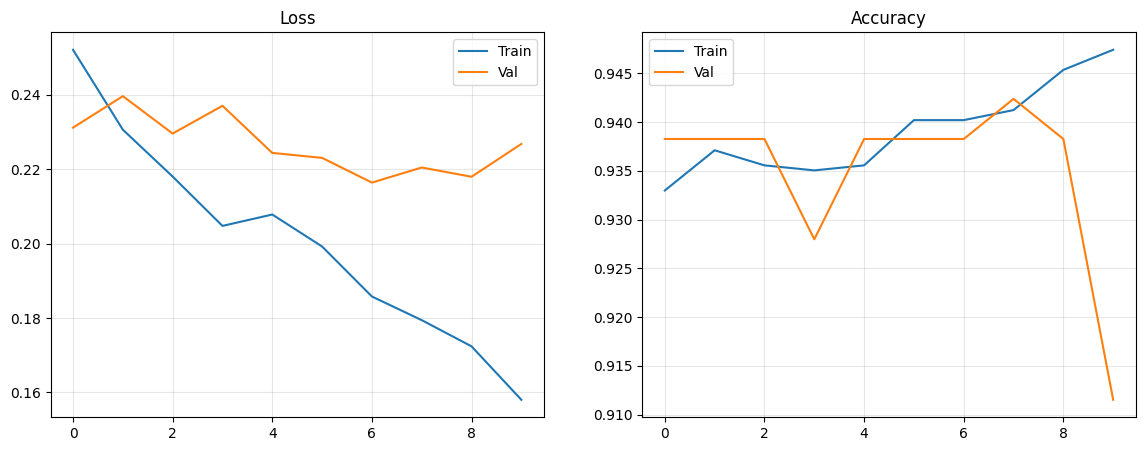


  LRCN-Original on dfdc
  Samples: 607 (568F, 39R, 14.56:1)
  Accuracy:          0.9292
  Balanced Accuracy: 0.7114
  Precision(Real):   0.45
  Recall(Real):      0.4615
  F1(Real):          0.4557
  Specificity:       0.9613
  ROC AUC:           0.7386
  Best threshold:    0.540 -> F1=0.4865
  Saved to results\dfdc\lrcn_original/
  Verification: From the LRCN-Original confusion matrix (TN=546, FP=22, FN=21, TP=18): Precision(Real)=0.45, Recall(...


In [9]:
tf.random.set_seed(SEED)
np.random.seed(SEED)

model_orig = Sequential([
    TimeDistributed(Dense(256, activation='relu'), input_shape=(T, F)),
    Dropout(0.3),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(2, activation='softmax', dtype='float32'),
])
model_orig.compile(loss='categorical_crossentropy',
                   optimizer=Adam(learning_rate=LRCN_LR), metrics=['accuracy'])
model_orig.summary()

y_train_cat = to_categorical(y_train, 2)
y_test_cat = to_categorical(y_test, 2)

history_orig = model_orig.fit(X_train, y_train_cat, validation_split=0.2,
                              epochs=LRCN_EPOCHS, batch_size=LRCN_BATCH, verbose=1)

y_proba_orig = model_orig.predict(X_test)
y_pred_orig = np.argmax(y_proba_orig, axis=1)
y_score_orig = y_proba_orig[:, 1]

out_orig = RESULTS_BASE / 'lrcn_original'
out_orig.mkdir(parents=True, exist_ok=True)
model_orig.save(str(out_orig / 'model.h5'))
metrics_orig = full_eval(y_test, y_pred_orig, y_score_orig,
                         'LRCN-Original', out_orig, history_orig)

## 10. LRCN Retrained (with Focal Loss)

Focal alpha: Fake=0.534, Real=7.826


Epoch 1/15


  1/141 [..............................] - ETA: 2:49 - loss: 0.6546 - accuracy: 0.4062

  7/141 [>.............................] - ETA: 1s - loss: 0.4963 - accuracy: 0.4643  

 13/141 [=>............................] - ETA: 1s - loss: 0.4628 - accuracy: 0.4784

...

Restoring model weights from the end of the best epoch: 9.


141/141 [==============================] - 1s 5ms/step - loss: 0.0862 - accuracy: 0.8393 - val_loss: 0.2858 - val_accuracy: 0.7133 - lr: 5.0000e-05


Epoch 13: early stopping


 1/19 [>.............................] - ETA: 3s

19/19 [==============================] - 0s 2ms/step


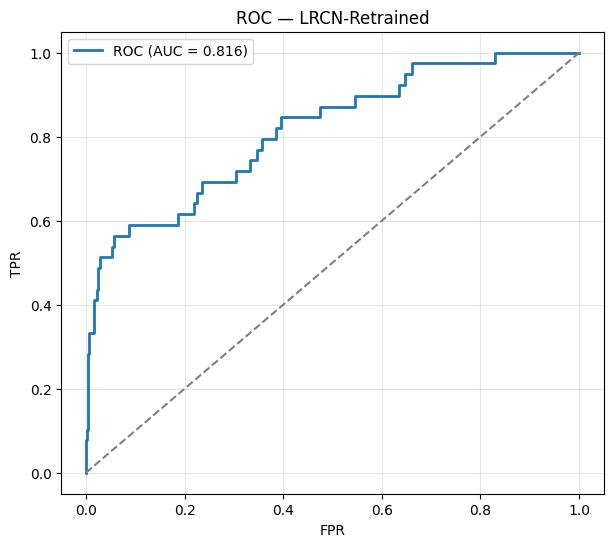

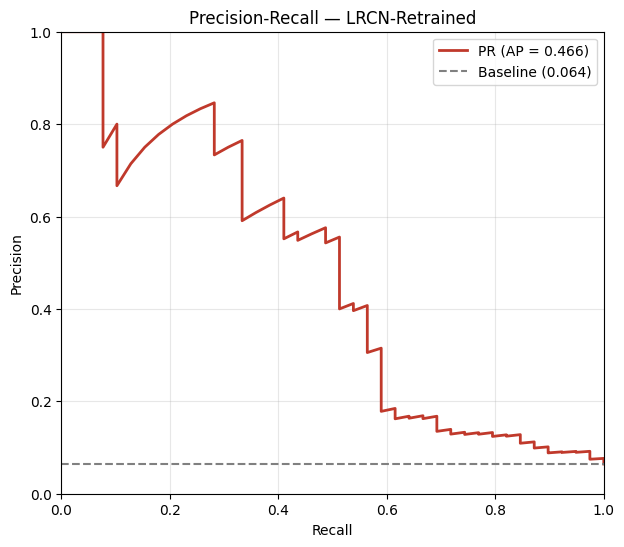

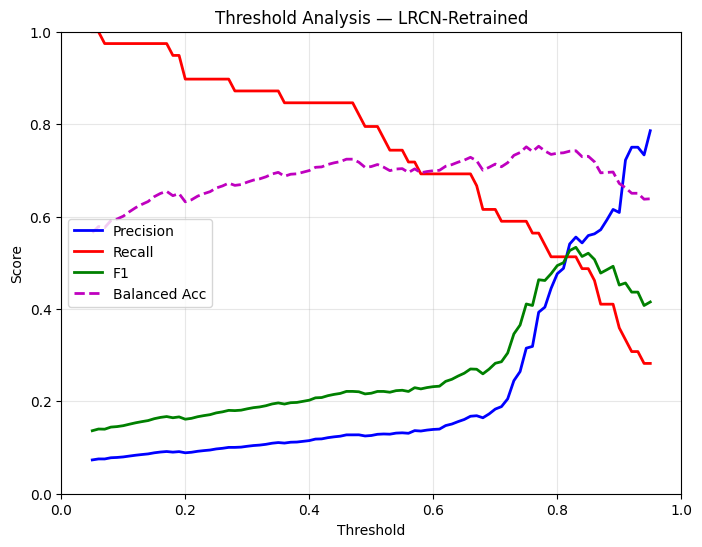

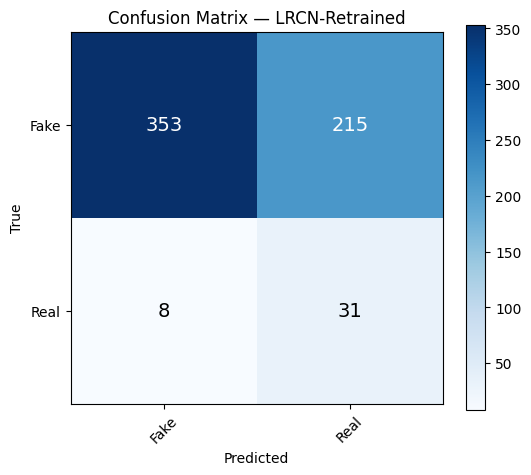

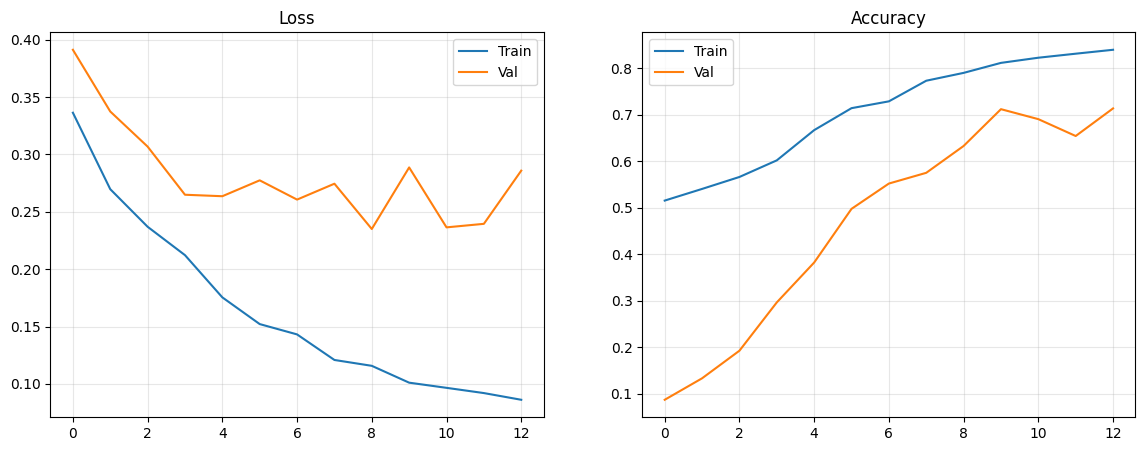


  LRCN-Retrained on dfdc
  Samples: 607 (568F, 39R, 14.56:1)
  Accuracy:          0.6326
  Balanced Accuracy: 0.7082
  Precision(Real):   0.126
  Recall(Real):      0.7949
  F1(Real):          0.2175
  Specificity:       0.6215
  ROC AUC:           0.8162
  Best threshold:    0.830 -> F1=0.5333
  Saved to results\dfdc\lrcn_retrained/
  Verification: From the LRCN-Retrained confusion matrix (TN=353, FP=215, FN=8, TP=31): Precision(Real)=0.126, Recal...


In [10]:
class BalancedGen(KerasSequence):
    def __init__(self, X, y, bs, seed=SEED):
        self.X, self.y, self.half = X, y, bs//2
        self.rng = np.random.RandomState(seed)
        self.pos = np.where(y==1)[0]
        self.neg = np.where(y==0)[0]
    def __len__(self):
        return max(max(len(self.pos), len(self.neg)) // self.half, 1)
    def __getitem__(self, i):
        p = self.rng.choice(self.pos, self.half, replace=True)
        n = self.rng.choice(self.neg, self.half, replace=True)
        b = np.concatenate([p, n]); self.rng.shuffle(b)
        return self.X[b], to_categorical(self.y[b], 2)
    def on_epoch_end(self):
        self.rng.shuffle(self.pos); self.rng.shuffle(self.neg)

n0 = int((y_train==0).sum())
n1 = int((y_train==1).sum())
alpha_vec = [(n0+n1)/(2.0*n0), (n0+n1)/(2.0*n1)]
print(f'Focal alpha: Fake={alpha_vec[0]:.3f}, Real={alpha_vec[1]:.3f}')

alpha_t = tf.constant(alpha_vec, dtype=tf.float32)
def focal_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
    ce = -y_true * tf.math.log(y_pred)
    w = alpha_t * tf.pow(1.0 - y_pred, FOCAL_GAMMA)
    return tf.reduce_mean(tf.reduce_sum(w * ce, axis=1))

tf.random.set_seed(SEED)
np.random.seed(SEED)

model_ret = Sequential([
    TimeDistributed(Dense(256, activation='relu'), input_shape=(T, F)),
    Dropout(0.3),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(2, activation='softmax', dtype='float32'),
])
model_ret.compile(optimizer=Adam(learning_rate=RETRAIN_LR),
                  loss=focal_loss, metrics=['accuracy'])

train_gen = BalancedGen(X_train, y_train, RETRAIN_BATCH)
cbs = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
]

history_ret = model_ret.fit(train_gen, validation_data=(X_test, y_test_cat),
                            epochs=RETRAIN_EPOCHS, callbacks=cbs, verbose=1)

y_proba_ret = model_ret.predict(X_test)
y_pred_ret = np.argmax(y_proba_ret, axis=1)
y_score_ret = y_proba_ret[:, 1]

out_ret = RESULTS_BASE / 'lrcn_retrained'
out_ret.mkdir(parents=True, exist_ok=True)
model_ret.save(str(out_ret / 'model.h5'))
metrics_ret = full_eval(y_test, y_pred_ret, y_score_ret,
                        'LRCN-Retrained', out_ret, history_ret)

## 11. SVM Evaluation (per-frame, original protocol)

The original SVM evaluation treats each extracted face frame as an independent sample.
We flatten the 15-frame sequences into individual VGG16 feature vectors (each 512-d),
giving N×15 per-frame samples. This matches the original `Final.py` evaluation protocol.

Config: RBF kernel, C=1.0, γ=scale, probability=True, no standardization, seed=42 (R#4 Point 5)

**Additionally**, we aggregate per-frame probabilities back to per-video predictions
(mean probability over 15 frames) for direct comparison with LRCN.

SVM: Train=12130 frames (5/video)
SVM: Test =9105 frames (15/video)
  Test: Fake=8520, Real=585


Trained in 5.5s | SVs: [1464  775]



-- SVM Per-Frame Results (N=9105) --


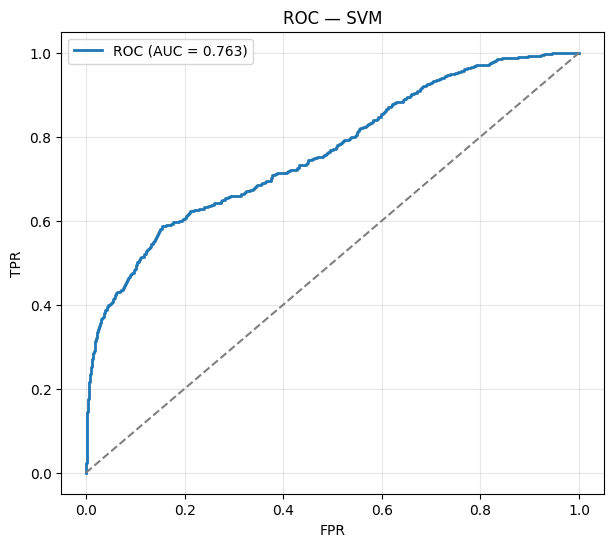

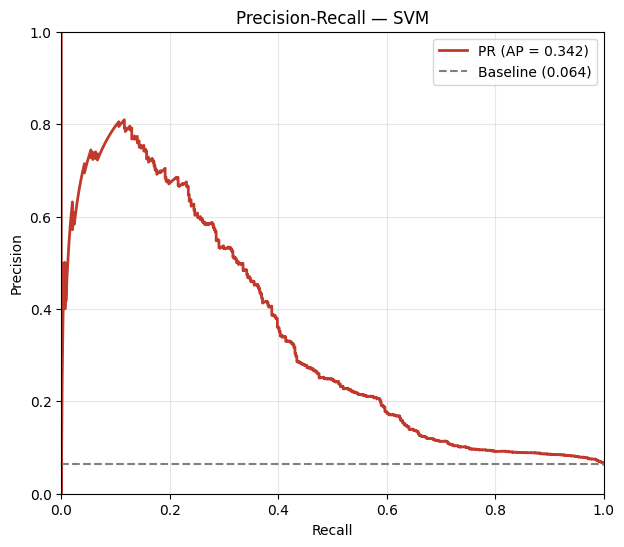

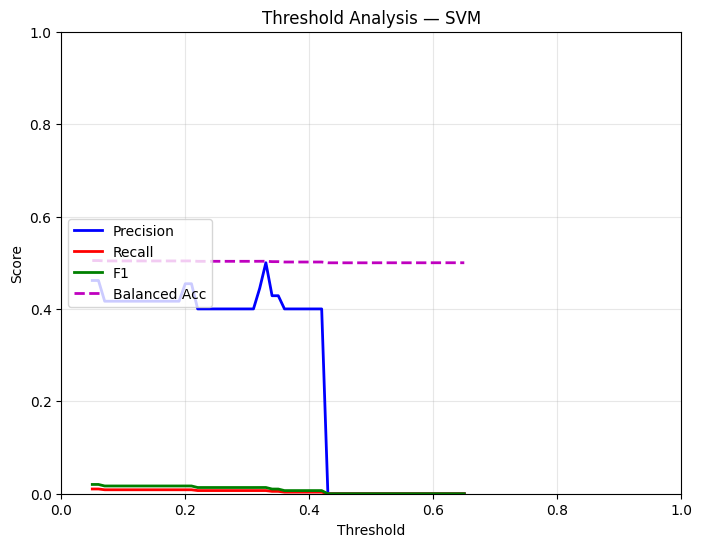

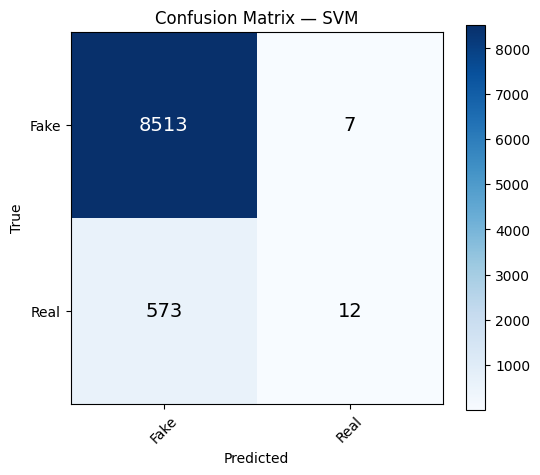


  SVM on dfdc
  Samples: 9105 (8520F, 585R, 14.56:1)
  Accuracy:          0.9363
  Balanced Accuracy: 0.5098
  Precision(Real):   0.6316
  Recall(Real):      0.0205
  F1(Real):          0.0397
  Specificity:       0.9992
  ROC AUC:           0.7633
  Best threshold:    0.050 -> F1=0.0201
  Saved to results\dfdc\svm/
  Verification: From the SVM confusion matrix (TN=8513, FP=7, FN=573, TP=12): Precision(Real)=0.6316, Recall(Real)=0...



-- SVM Per-Video (N=607, mean over 15 frames) --


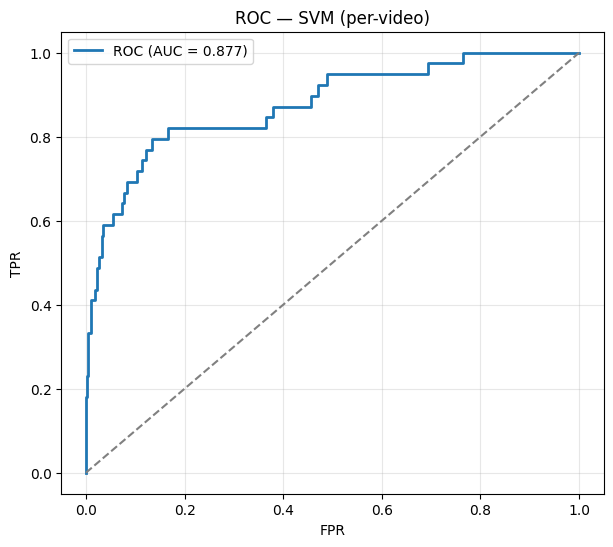

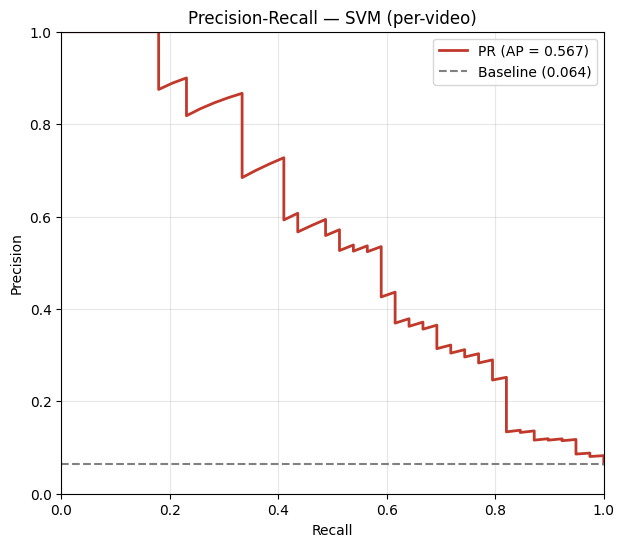

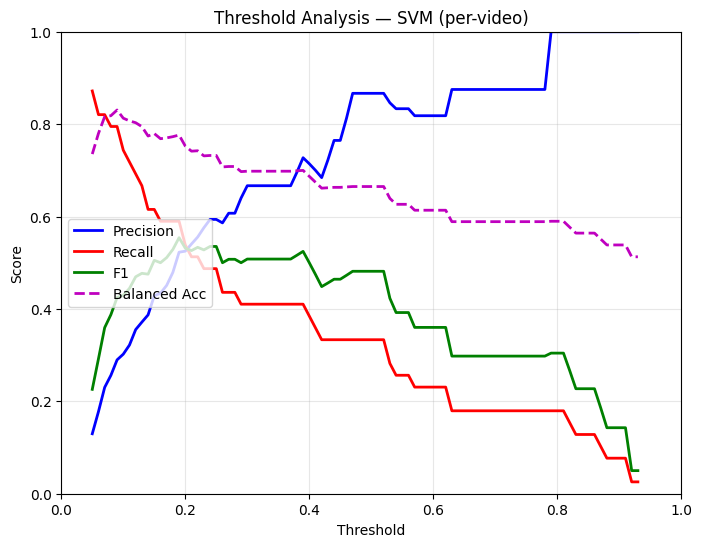

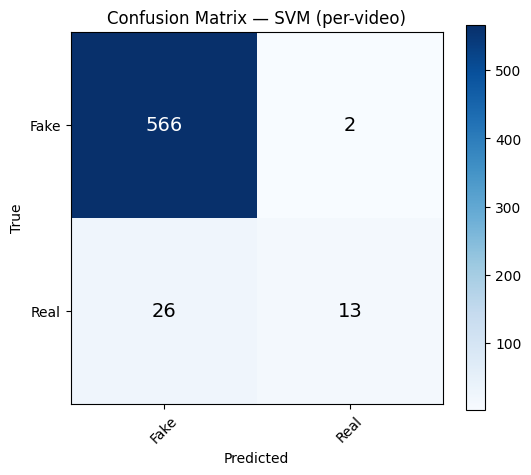


  SVM (per-video) on dfdc
  Samples: 607 (568F, 39R, 14.56:1)
  Accuracy:          0.9539
  Balanced Accuracy: 0.6649
  Precision(Real):   0.8667
  Recall(Real):      0.3333
  F1(Real):          0.4815
  Specificity:       0.9965
  ROC AUC:           0.8773
  Best threshold:    0.190 -> F1=0.5542
  Saved to results\dfdc\svm_per_video/
  Verification: From the SVM (per-video) confusion matrix (TN=566, FP=2, FN=26, TP=13): Precision(Real)=0.8667, Reca...
SVM models saved to results\dfdc\svm/


In [11]:
# SVM: Per-frame evaluation (original protocol)
# Train on 5 evenly-spaced frames per video, test on all 15.
# Each VGG16 feature vector is an individual SVM sample.
from sklearn.calibration import CalibratedClassifierCV

TRAIN_FRAMES = [0, 3, 7, 11, 14]  # 5 evenly-spaced from 15

# Training: subsample 5 frames per video
X_train_sub = X_train[:, TRAIN_FRAMES, :]          # (N, 5, 512)
X_train_svm = X_train_sub.reshape(-1, X_train_sub.shape[-1])  # (N*5, 512)
y_train_svm = np.repeat(y_train, len(TRAIN_FRAMES))

# Testing: all 15 frames per video
X_test_svm = X_test.reshape(-1, X_test.shape[-1])  # (N*15, 512)
y_test_svm = np.repeat(y_test, SEQUENCE_LENGTH)

print(f"SVM: Train={len(X_train_svm)} frames ({len(TRAIN_FRAMES)}/video)")
print(f"SVM: Test ={len(X_test_svm)} frames ({SEQUENCE_LENGTH}/video)")
print(f"  Test: Fake={(y_test_svm==0).sum()}, Real={(y_test_svm==1).sum()}")

# Train SVM (RBF, C=1.0, gamma=scale, no standardization)
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)
t0 = time.perf_counter()
svm.fit(X_train_svm, y_train_svm)
print(f"Trained in {time.perf_counter()-t0:.1f}s | SVs: {svm.n_support_}")

# Per-frame predictions
y_pred_svm  = svm.predict(X_test_svm)
y_score_svm = svm.decision_function(X_test_svm)

out_svm = RESULTS_BASE / "svm"
print("\n-- SVM Per-Frame Results (N=" + str(len(y_test_svm)) + ") --")
metrics_svm = full_eval(y_test_svm, y_pred_svm, y_score_svm, "SVM", out_svm)

# Calibrate for per-video aggregation (Platt scaling)
cal_svm = CalibratedClassifierCV(svm, method="sigmoid", cv="prefit")
cal_svm.fit(X_train_svm, y_train_svm)
y_proba_svm = cal_svm.predict_proba(X_test_svm)[:, 1]

# Per-video: mean calibrated probability over 15 frames
y_proba_vid = y_proba_svm.reshape(-1, SEQUENCE_LENGTH).mean(axis=1)
y_pred_vid  = (y_proba_vid >= 0.5).astype(int)

out_svm_vid = RESULTS_BASE / "svm_per_video"
print("\n-- SVM Per-Video (N=" + str(len(y_test)) + ", mean over " + str(SEQUENCE_LENGTH) + " frames) --")
metrics_svm_vid = full_eval(y_test, y_pred_vid, y_proba_vid,
                            "SVM (per-video)", out_svm_vid)

# Save models
import joblib
joblib.dump(svm, str(out_svm / "svm_model.pkl"))
joblib.dump(cal_svm, str(out_svm / "svm_calibrated.pkl"))
print("SVM models saved to " + str(out_svm) + "/")

## 12. Pipeline Timing (R#4 Point 7)

In [12]:
model_orig = load_model(str(RESULTS_BASE / 'lrcn_original' / 'model.h5'))
print('✅ Model loaded for timing')

timing_videos = (real_videos + fake_videos)[:NUM_TIMING_VIDEOS]
timings = {'face_det': [], 'vgg': [], 'classifier': [], 'total': []}

for vp in tqdm(timing_videos, desc='Timing'):
    t0 = time.perf_counter()
    faces, _ = extract_faces_from_video(vp)
    t1 = time.perf_counter()
    features = faces_to_features(faces, vgg)
    t2 = time.perf_counter()
    _ = model_orig.predict(np.expand_dims(features, 0), verbose=0)
    t3 = time.perf_counter()
    timings['face_det'].append(t1-t0)
    timings['vgg'].append(t2-t1)
    timings['classifier'].append(t3-t2)
    timings['total'].append(t3-t0)

print(f"\n{'Stage':<18} {'Mean (s)':<12} {'Std (s)':<12}")
print('-' * 42)
timing_stats = {}
for k in ['face_det', 'vgg', 'classifier', 'total']:
    v = np.array(timings[k])
    timing_stats[k] = {'mean': round(v.mean(), 4), 'std': round(v.std(), 4)}
    print(f"{k:<18} {v.mean():<12.4f} {v.std():<12.4f}")

with open(RESULTS_BASE / 'pipeline_timing.json', 'w') as f:
    json.dump({'n_videos': len(timing_videos), 'stats': timing_stats}, f, indent=2)

t = timing_stats['total']
print(f"\nFor paper: VeriLens classifies a single video ({SEQUENCE_LENGTH} frames) "
      f"in {t['mean']:.3f} +/- {t['std']:.3f} seconds.")

✅ Model loaded for timing


Timing:   0%|          | 0/10 [00:00<?, ?it/s]

Timing:  10%|█         | 1/10 [00:04<00:36,  4.06s/it]

Timing:  20%|██        | 2/10 [00:05<00:19,  2.44s/it]

Timing:  30%|███       | 3/10 [00:07<00:14,  2.10s/it]

...

Timing:  80%|████████  | 8/10 [00:13<00:02,  1.44s/it]

Timing:  90%|█████████ | 9/10 [00:15<00:01,  1.43s/it]

Timing: 100%|██████████| 10/10 [00:16<00:00,  1.46s/it]

Timing: 100%|██████████| 10/10 [00:16<00:00,  1.69s/it]


Stage              Mean (s)     Std (s)     
------------------------------------------
face_det           1.2809       0.1915      
vgg                0.3551       0.5739      
classifier         0.0559       0.0597      
total              1.6919       0.7959      

For paper: VeriLens classifies a single video (15 frames) in 1.692 +/- 0.796 seconds.


## 13. Comparative Summary

In [13]:
metrics_orig = json.load(open(RESULTS_BASE / 'lrcn_original' / 'metrics.json'))
metrics_ret = json.load(open(RESULTS_BASE / 'lrcn_retrained' / 'metrics.json'))
metrics_svm = json.load(open(RESULTS_BASE / 'svm' / 'metrics.json'))
metrics_svm_vid = json.load(open(RESULTS_BASE / 'svm_per_video' / 'metrics.json'))

print(f"\n{'='*80}")
print(f"  COMPARATIVE SUMMARY — {DATASET_NAME.upper()}")
print(f"{'='*80}")

header = f"  {'Model':<28} {'Eval':<10} {'Prec':<8} {'Rec':<8} {'F1':<8} {'Acc':<8} {'BalAcc':<8} {'AUC':<8}"
print(f'\n{header}')
print('  ' + '-'*len(header))
for name, m, ev in [
    ('LRCN-Original',   metrics_orig,    'per-vid'),
    ('LRCN-Retrained',  metrics_ret,     'per-vid'),
    ('SVM',             metrics_svm,     'per-frm'),
    ('SVM (aggregated)',metrics_svm_vid,  'per-vid'),
]:
    print(f"  {name:<28} {ev:<10} "
          f"{m['precision_real']:<8} "
          f"{m['recall_real']:<8} "
          f"{m['f1_real']:<8} "
          f"{m['accuracy']:<8} "
          f"{m['balanced_accuracy']:<8} "
          f"{m.get('roc_auc','N/A'):<8}")

print(f"\n  Note: LRCN evaluated per-video ({metrics_orig['total_samples']} sequences).")
print(f"  SVM evaluated per-frame ({metrics_svm['total_samples']} samples from "
      f"{metrics_svm_vid['total_samples']} videos × {SEQUENCE_LENGTH} frames).")
print(f"  SVM (aggregated) = mean probability over {SEQUENCE_LENGTH} frames → per-video prediction.")

with open(RESULTS_BASE / 'comparative_summary.json', 'w') as f:
    json.dump({
        'lrcn_original': metrics_orig,
        'lrcn_retrained': metrics_ret,
        'svm_per_frame': metrics_svm,
        'svm_per_video': metrics_svm_vid,
    }, f, indent=2)

print(f"\nAll results in {RESULTS_BASE}/")


  COMPARATIVE SUMMARY — DFDC

  Model                        Eval       Prec     Rec      F1       Acc      BalAcc   AUC     
  -----------------------------------------------------------------------------------------------
  LRCN-Original                per-vid    0.45     0.4615   0.4557   0.9292   0.7114   0.7386  
  LRCN-Retrained               per-vid    0.126    0.7949   0.2175   0.6326   0.7082   0.8162  
  SVM                          per-frm    0.6316   0.0205   0.0397   0.9363   0.5098   0.7633  
  SVM (aggregated)             per-vid    0.8667   0.3333   0.4815   0.9539   0.6649   0.8773  

  Note: LRCN evaluated per-video (607 sequences).
  SVM evaluated per-frame (9105 samples from 607 videos × 15 frames).
  SVM (aggregated) = mean probability over 15 frames → per-video prediction.

All results in results\dfdc/


## 14. Verification Paragraphs (copy to Section 4.3)

In [14]:
for name, d in [('lrcn_original', 'LRCN-Original'),
                ('lrcn_retrained', 'LRCN-Retrained'),
                ('svm', 'SVM (per-frame)'),
                ('svm_per_video', 'SVM (per-video)')]:
    vfile = RESULTS_BASE / name / 'verification.txt'
    if vfile.exists():
        print(f'\n{d}:')
        print(f'  {vfile.read_text()}\n')


LRCN-Original:
  From the LRCN-Original confusion matrix (TN=546, FP=22, FN=21, TP=18): Precision(Real)=0.45, Recall(Real)=0.4615, Accuracy=0.9292, F1(Real)=0.4557, Specificity=0.9613, Balanced Accuracy=0.7114.


LRCN-Retrained:
  From the LRCN-Retrained confusion matrix (TN=353, FP=215, FN=8, TP=31): Precision(Real)=0.126, Recall(Real)=0.7949, Accuracy=0.6326, F1(Real)=0.2175, Specificity=0.6215, Balanced Accuracy=0.7082.


SVM (per-frame):
  From the SVM confusion matrix (TN=8513, FP=7, FN=573, TP=12): Precision(Real)=0.6316, Recall(Real)=0.0205, Accuracy=0.9363, F1(Real)=0.0397, Specificity=0.9992, Balanced Accuracy=0.5098.


SVM (per-video):
  From the SVM (per-video) confusion matrix (TN=566, FP=2, FN=26, TP=13): Precision(Real)=0.8667, Recall(Real)=0.3333, Accuracy=0.9539, F1(Real)=0.4815, Specificity=0.9965, Balanced Accuracy=0.6649.

